# Exercise: Performance Evaluation

The goal of this exercise is to illustrate how the performance of a neural network can be evaluated. After training the model, you can analyze the learning curves and values related to the model performance such as: 
- Error training
- Error development test
- Error bias
- Error variance
- Training time

## Libraries

In [3]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
from sklearn.metrics import classification_report

print("Tensorflow version: "+tf.__version__)

Tensorflow version: 2.16.2


## Datasets

In [5]:
ATT_FILE =   "MedianHouseValuePreparedCleanAttributes.csv"
LABEL_FILE = "MedianHouseValueOneHotEncodedClasses.csv"

attributes = pd.read_csv(ATT_FILE)
label =      pd.read_csv(LABEL_FILE)

TRAIN_RATIO = 0.8

n_instances = attributes.shape[0]
n_train = int(n_instances*TRAIN_RATIO)
n_dev = int((n_instances - n_train)/2)

x_train = attributes.values[:n_train]
t_train = label.values[:n_train]
x_dev =   attributes.values[n_train:n_train + n_dev]
t_dev =   label.values[n_train:n_train + n_dev]

INPUTS =  x_train.shape[1]
OUTPUTS = t_train.shape[1]

NUM_TRAINING_EXAMPLES = int(round(x_train.shape[0]/1))
NUM_DEV_EXAMPLES =      int(round(x_dev.shape[0]/1))

print ("Number of inputs: ", INPUTS)
print ("Number of outputs: ", OUTPUTS)
print ("Number of examples for training: ", NUM_TRAINING_EXAMPLES)
print ("Number of examples for development test: ", NUM_DEV_EXAMPLES)

Number of inputs:  9
Number of outputs:  3
Number of examples for training:  16342
Number of examples for development test:  2043


## Hyperparameters

In [7]:
ACTIVATION_FUNCTION = "relu"
LEARNING_RATE = 0.01
EPOCHS = 200
BATCH_SIZE = 32
OPTIMIZER = tf.keras.optimizers.SGD(learning_rate = LEARNING_RATE)

## Model


In [9]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.InputLayer(shape=(INPUTS,)))
model.add(tf.keras.layers.Dense(40, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(40, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(40, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(20, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(OUTPUTS, activation="softmax"))

model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=OPTIMIZER,
              metrics=["categorical_accuracy"])


## Training

In [11]:
start_time = time.perf_counter()

history = model.fit(x_train, t_train,
                    batch_size = BATCH_SIZE,
                    epochs = EPOCHS,
                    verbose = 0,
                    validation_data = (x_dev, t_dev))

end_time = time.perf_counter()

## Results

In [13]:
def display_loss_curve(history):
    plt.figure(figsize=(8, 5))

    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="test loss")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Model Loss")
    plt.ylim(0, 1)
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

def display_error_curve(history):
    plt.figure(figsize=(8, 5))

    train_error = [1 - acc for acc in history.history["categorical_accuracy"]]
    test_error = [1 - acc for acc in history.history["val_categorical_accuracy"]]

    plt.plot(train_error, label="train error")
    plt.plot(test_error, label="test error")

    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.title("Model Error")
    plt.ylim(0, 1)
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()
    

Error training:  22.0 %
Error development test:  22.2 %
Error bias:  17.0 %
Error variance:  0.3 %
Time:  39 seconds


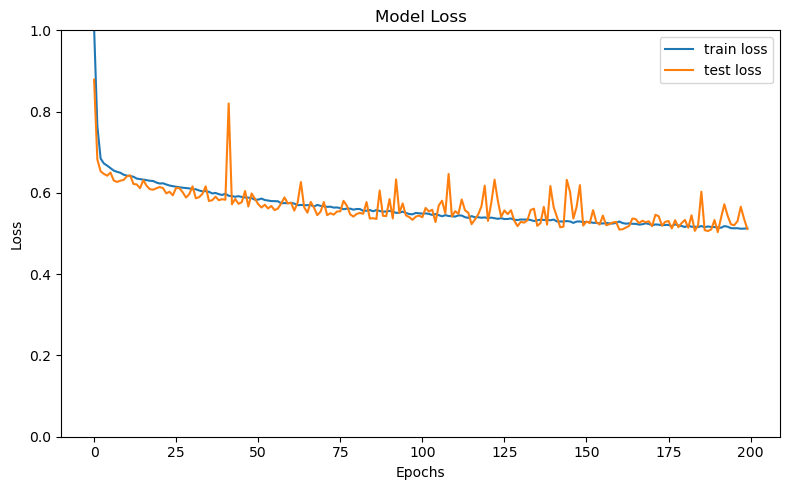

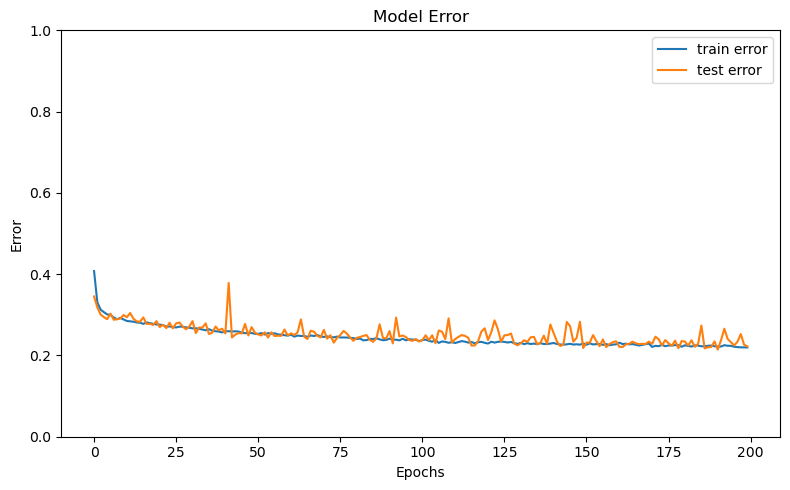

In [14]:
IRREDUCIBLE_ERROR = 0.05

results = pd.DataFrame(history.history)

error_training = (1 - results.categorical_accuracy.values[-1:][0])*100
error_test = (1 - results.val_categorical_accuracy.values[-1:][0])*100
error_bias = error_training - IRREDUCIBLE_ERROR*100
error_variance = error_test - error_training

print ("Error training: ", round(error_training,1), "%")
print ("Error development test: ", round(error_test, 1), "%")
print ("Error bias: ", round(error_bias, 1), "%")
print ("Error variance: ", round(error_variance, 1), "%")
print ("Time: ", round((end_time - start_time)),"seconds")

display_loss_curve(history)

display_error_curve(history)